# Statistical Fishing Effort Classification
## Enhanced Rule-Based Classifier with Configurable Parameters

---

This notebook demonstrates the **enhanced statistical classifier** for identifying fishing effort from GPS vessel tracks.

### 📊 Behavioral Indicators

The classifier analyzes multiple fishing behavior patterns (the complete parameters at the end of this notebook):

| Feature | Fishing Behavior | Non-Fishing |
|---------|-----------------|-------------|
| **Speed** | 0.5-8 km/h (gear deployment) | <0.5 or >10 km/h |
| **Turning** | High turn angles (>40°) | Straight paths |
| **Path Straightness** | Low (<0.45) - meandering | High (>0.7) - direct |
| **Spatial Clustering** | Repeated operations in area | Transiting through |
| **Speed Variability** | Start-stop behavior | Constant speed |
| **Sinuosity** | Tortuous paths (>1.5) | Straight lines (~1.0) |

---

## 1. Setup & Imports

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# SSF-AI-Toolkit utilities
from ssfaitk.utils.trip_file_loader import load_random_trips
from ssfaitk.utils.plot_trip_route import plot_trip_route, plot_trip_route_png

# Statistical effort classifiers
# NOTE: Import both old and new versions for comparison
from ssfaitk.models.effort.statistical_effort import StatisticalEffortClassifier as OldClassifier
from ssfaitk.models.effort.statistical_effort_v2 import StatisticalEffortClassifier as NewClassifier

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

# Output directory
OUTPUT_DIR = "fishing_effort_outputs"
Path(OUTPUT_DIR).mkdir(exist_ok=True)

print("✓ Libraries imported successfully")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Libraries imported successfully
✓ Output directory: fishing_effort_outputs


---
## 2. Load Your GPS Data

### Option 1: Load Random Trips from Directory

Use the built-in `load_random_trips` utility to load sample trips.

In [2]:
# ==============================================================================
# CONFIGURE DATA LOADING
# ==============================================================================


# How many trips to load (for testing)
N_TRIPS = 5

# Random seed for reproducibility
SEED = 42

# Load trips
print(f"Loading {N_TRIPS} random trips")
print("="*70)

df = load_random_trips(n=N_TRIPS, country='zanzibar', seed=SEED)

print(f"\n✓ Loaded {N_TRIPS} trips!")
print(f"✓ Data loaded: {len(df):,} rows, {len(df.columns)} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Found 8223 trips in /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar
Randomly selected 5 trips (seed=42)
Selected trip IDs: ['14517537' '14382277' '13570346' '13260243' '14460963']
Loading 5 trips...
Loading trip 14517537 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_14517537.parquet
Loaded 5,150 points for trip 14517537
  [1/5] Trip 14517537: 5,150 points ✓
Loading trip 14382277 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_14382277.parquet
Loaded 433 points for trip 14382277
  [2/5] Trip 14382277: 433 points ✓
Loading trip 13570346 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_13570346.parquet
Loaded 694 points for trip 13570346
  [3/5] Trip 13570346: 694 points ✓
Loading trip 13260243 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tra

Loading 5 random trips

✓ Loaded 5 trips!
✓ Data loaded: 14,472 rows, 10 columns

Columns: ['Time', 'Boat', 'Trip', 'Lat', 'Lng', 'Speed (M/S)', 'Range (Meters)', 'Heading', 'Boat Name', 'Community']

First few rows:


,Time,Boat,Trip,Lat,Lng,Speed (M/S),Range (Meters),Heading,Boat Name,Community
0,2026-01-26 23:23:00+00:00,24539.0,1.4518e+07,-4.9009,39.7327,0.00,0.0000,49.0,Kwa roho safi,"Msuka Magharibi,2026-01-29 09:29:10+00,2026-01..."
1,2026-01-26 23:28:45+00:00,24539.0,1.4518e+07,-4.9009,39.7327,0.01,5.9575,74.0,Kwa roho safi,"Msuka Magharibi,2026-01-29 09:29:10+00,2026-01..."
2,2026-01-26 23:34:30+00:00,24539.0,1.4518e+07,-4.9009,39.7327,0.01,4.9573,44.0,Kwa roho safi,"Msuka Magharibi,2026-01-29 09:29:10+00,2026-01..."
3,2026-01-26 23:40:15+00:00,24539.0,1.4518e+07,-4.9009,39.7327,0.00,7.0937,54.0,Kwa roho safi,"Msuka Magharibi,2026-01-29 09:29:10+00,2026-01..."
4,2026-01-26 23:46:00+00:00,24539.0,1.4518e+07,-4.9009,39.7328,0.02,2.4787,46.0,Kwa roho safi,"Msuka Magharibi,2026-01-29 09:29:10+00,2026-01..."


### Option 2: Load from CSV/Parquet

If you have a single file instead of trip directory:

In [6]:
# Uncomment to load from CSV instead
# df = pd.read_csv('your_fishing_tracks.csv')

# Uncomment to load from Parquet instead
# df = pd.read_parquet('your_fishing_tracks.parquet')

print("Using data from previous cell")

Using data from previous cell


### Data Summary & Validation

In [7]:
# Display data summary
print("DATA SUMMARY")
print("="*70)
print(f"\nTotal GPS Points: {len(df):,}")

# Check for required columns (adjust based on your data)
if 'Trip' in df.columns:
    print(f"Total Trips: {df['Trip'].nunique()}")
    print(f"\nTrips loaded:")
    for trip_id, trip_data in df.groupby('Trip'):
        print(f"  Trip {trip_id}: {len(trip_data):,} points")

if 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'])
    print(f"\nDate Range: {df['Time'].min()} to {df['Time'].max()}")
    duration_hours = (df['Time'].max() - df['Time'].min()).total_seconds() / 3600
    print(f"Total Duration: {duration_hours:.1f} hours")

print(f"\n✓ Data ready for classification")

DATA SUMMARY

Total GPS Points: 14,472
Total Trips: 5

Trips loaded:
  Trip 13260243.0: 5,113 points
  Trip 13570346.0: 694 points
  Trip 14382277.0: 433 points
  Trip 14460963.0: 3,082 points
  Trip 14517537.0: 5,150 points

Date Range: 2025-03-18 13:00:59+00:00 to 2026-01-29 08:43:52+00:00
Total Duration: 7603.7 hours

✓ Data ready for classification


---
## 3. Classification with Default Configuration

### Initialize Classifier with Default Settings

The new classifier (v2) has enhanced features and sensible defaults.

In [8]:
# Initialize new classifier with default configuration
clf_v2_default = NewClassifier()

print("Default Configuration (Enhanced v2):")
print("="*70)
print(f"\n📊 SPEED THRESHOLDS:")
print(f"  Fishing speed range:    {clf_v2_default.config['min_fishing_speed']:.1f} - {clf_v2_default.config['max_fishing_speed']:.1f} km/h")
print(f"  Transit speed:          > {clf_v2_default.config['min_transit_speed']:.1f} km/h")

print(f"\n🔄 TURNING THRESHOLDS:")
print(f"  High turn threshold:    > {clf_v2_default.config['high_turn_threshold']:.1f}°")
print(f"  Min distance for turn:  {clf_v2_default.config['min_distance_for_turn']:.2f} km")

print(f"\n🛤️  PATH THRESHOLDS:")
print(f"  Low straightness:       < {clf_v2_default.config['low_straightness_threshold']:.2f}")
print(f"  High sinuosity:         > {clf_v2_default.config['high_sinuosity_threshold']:.2f}")

print(f"\n📍 SPATIAL THRESHOLDS:")
print(f"  Clustering radius:      {clf_v2_default.config['clustering_radius_km']:.1f} km")
print(f"  Spatial window:         {clf_v2_default.config['spatial_window_km']:.1f} km")

print(f"\n⚙️  CLASSIFICATION SETTINGS:")
print(f"  Fishing score threshold: {clf_v2_default.config['fishing_score_threshold']:.2f}")
print(f"  Min state duration:      {clf_v2_default.config['min_state_duration']} points")
print(f"  Time windows:            {clf_v2_default.config['time_windows']} minutes")

Default Configuration (Enhanced v2):

📊 SPEED THRESHOLDS:
  Fishing speed range:    0.5 - 8.0 km/h
  Transit speed:          > 12.0 km/h

🔄 TURNING THRESHOLDS:
  High turn threshold:    > 45.0°
  Min distance for turn:  0.10 km

🛤️  PATH THRESHOLDS:
  Low straightness:       < 0.40
  High sinuosity:         > 1.50

📍 SPATIAL THRESHOLDS:
  Clustering radius:      0.5 km
  Spatial window:         1.0 km

⚙️  CLASSIFICATION SETTINGS:
  Fishing score threshold: 0.50
  Min state duration:      3 points
  Time windows:            [10.0] minutes


### Run Prediction with Default Config

In [9]:
# Run prediction
print("Running classification with DEFAULT configuration...")

predictions_v2_default = clf_v2_default.predict(df.copy(), filter=True)

print("✓ Classification complete!")
print("="*70)

# Overall statistics
fishing_pct = predictions_v2_default['is_fishing'].mean() * 100
fishing_points = predictions_v2_default['is_fishing'].sum()
total_points = len(predictions_v2_default)

print(f"\n📊 OVERALL RESULTS (Default Config):")
print(f"  Total GPS points:       {total_points:,}")
print(f"  Fishing points:         {fishing_points:,} ({fishing_pct:.1f}%)")
print(f"  Non-fishing points:     {total_points - fishing_points:,} ({100-fishing_pct:.1f}%)")
print(f"  Average fishing score:  {predictions_v2_default['fishing_score'].mean():.3f}")

# Per-trip summary
if 'trip_id' in predictions_v2_default.columns:
    print(f"\n📋 PER-TRIP SUMMARY:")
    print("-"*70)
    for trip_id in predictions_v2_default['trip_id'].unique():
        trip_data = predictions_v2_default[predictions_v2_default['trip_id'] == trip_id]
        trip_fishing = trip_data['is_fishing'].sum()
        trip_total = len(trip_data)
        trip_pct = (trip_fishing / trip_total * 100) if trip_total > 0 else 0
        print(f"  Trip {trip_id}: {trip_fishing:,}/{trip_total:,} fishing ({trip_pct:.1f}%)")

Resolved columns: lat=Lat, lon=Lng, time=Time, trip=Trip
Processing 14472 points across 5 trips
Computing kinematic features (with improved turn angle filtering)...
Computing local statistics (time-based windows: [10.0] min)...
Computing spatial features (distance-based window: 1.0 km)...


Running classification with DEFAULT configuration...


Computing temporal features...
Applying statistical classification rules (with feature interactions)...
Classification complete: 10.7% classified as fishing
State machine smoothing applied (min duration: 3 points)
Applying shore filtering (region: None)...
  Method: coastline
  Min distance from coast: 0.5 km
  Filter land points: True
  Filter only fishing: True
Region 'wio' bbox: (-27.0, -0.5, 32.0, 42.0)
Loading: /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/data/coastline/coastline_lines_wio.shp
✓ Coastline: 1247 segments
Loading land: /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/data/coastline/coastline_land_wio.shp
✓ Land: 719 polygons
Filter mode: Only processing 1,546 fishing points (skipping 12,926 non-fishing)
Computing distances for 1,546 points...
✓ On land: 0 (0.0% of processed)
✓ Skipped 12,926 non-fishing points (dist set to 999 km)
Total filtered: 115 (0.79%)
Shore filtering complete:
  Original fishing points: 1,546
  After filtering: 1,546
  Removed (la

✓ Classification complete!

📊 OVERALL RESULTS (Default Config):
  Total GPS points:       14,472
  Fishing points:         1,546 (10.7%)
  Non-fishing points:     12,926 (89.3%)
  Average fishing score:  0.130

📋 PER-TRIP SUMMARY:
----------------------------------------------------------------------
  Trip 13260243.0: 0/5,113 fishing (0.0%)
  Trip 13570346.0: 166/694 fishing (23.9%)
  Trip 14382277.0: 0/433 fishing (0.0%)
  Trip 14460963.0: 543/3,082 fishing (17.6%)
  Trip 14517537.0: 837/5,150 fishing (16.3%)


---
## 4. Customize Configuration

### Pre-Defined Configuration Templates

Choose from these templates or create your own custom configuration.

In [6]:
# ==============================================================================
# PRE-DEFINED CONFIGURATION TEMPLATES
# ==============================================================================

# 1. HIGH SENSITIVITY CONFIG (catches more fishing - use if under-detecting)
HIGH_SENSITIVITY_CONFIG = {
    'fishing_score_threshold': 0.35,      # Lower threshold = more sensitive
    'min_fishing_speed': 0.2,
    'max_fishing_speed': 10.0,            # Wider speed range
    'min_transit_speed': 12.0,
    'high_turn_threshold': 35.0,          # Lower = detects gentler turns
    'low_straightness_threshold': 0.50,
    'high_sinuosity_threshold': 1.4,
    'clustering_radius_km': 1.2,
    'high_speed_cv_threshold': 0.5,
    'min_state_duration': 1,              # No smoothing
    'min_distance_for_turn': 0.05,
}

# 2. LOW SENSITIVITY CONFIG (more conservative - use if over-detecting)
LOW_SENSITIVITY_CONFIG = {
    'fishing_score_threshold': 0.55,      # Higher threshold = less sensitive
    'min_fishing_speed': 0.5,
    'max_fishing_speed': 7.0,             # Narrower speed range
    'min_transit_speed': 8.0,
    'high_turn_threshold': 45.0,
    'low_straightness_threshold': 0.40,
    'high_sinuosity_threshold': 1.6,
    'clustering_radius_km': 0.8,
    'high_speed_cv_threshold': 0.7,
    'min_state_duration': 3,              # More smoothing
    'min_distance_for_turn': 0.1,
}

# 3. GILLNET CONFIGURATION
GILLNET_CONFIG = {
    'fishing_score_threshold': 0.38,
    'min_fishing_speed': 0.3,
    'max_fishing_speed': 4.0,             # Gillnets = slower
    'min_transit_speed': 5.0,
    'high_turn_threshold': 35.0,          # More turning
    'low_straightness_threshold': 0.50,
    'high_sinuosity_threshold': 1.5,
    'clustering_radius_km': 0.6,          # More clustered
    'high_speed_cv_threshold': 0.6,
    'min_state_duration': 2,
    'min_distance_for_turn': 0.05,
}

# 4. TRAWL CONFIGURATION
TRAWL_CONFIG = {
    'fishing_score_threshold': 0.40,
    'min_fishing_speed': 2.0,
    'max_fishing_speed': 7.0,             # Trawls = faster
    'min_transit_speed': 8.0,
    'high_turn_threshold': 25.0,          # Less turning
    'low_straightness_threshold': 0.35,   # Straighter
    'high_sinuosity_threshold': 1.3,
    'clustering_radius_km': 2.0,          # More dispersed
    'high_speed_cv_threshold': 0.5,
    'min_state_duration': 2,
    'min_distance_for_turn': 0.1,
}

# 5. LONGLINE CONFIGURATION
LONGLINE_CONFIG = {
    'fishing_score_threshold': 0.40,
    'min_fishing_speed': 1.0,
    'max_fishing_speed': 6.0,
    'min_transit_speed': 8.0,
    'high_turn_threshold': 30.0,
    'low_straightness_threshold': 0.45,
    'high_sinuosity_threshold': 1.4,
    'clustering_radius_km': 1.0,
    'high_speed_cv_threshold': 0.6,
    'min_state_duration': 2,
    'min_distance_for_turn': 0.08,
}

print("✓ Configuration templates loaded:")
print("  1. HIGH_SENSITIVITY_CONFIG - For under-detection issues")
print("  2. LOW_SENSITIVITY_CONFIG - For over-detection issues")
print("  3. GILLNET_CONFIG - Optimized for gillnet fishing")
print("  4. TRAWL_CONFIG - Optimized for trawl fishing")
print("  5. LONGLINE_CONFIG - Optimized for longline fishing")

✓ Configuration templates loaded:
  1. HIGH_SENSITIVITY_CONFIG - For under-detection issues
  2. LOW_SENSITIVITY_CONFIG - For over-detection issues
  3. GILLNET_CONFIG - Optimized for gillnet fishing
  4. TRAWL_CONFIG - Optimized for trawl fishing
  5. LONGLINE_CONFIG - Optimized for longline fishing


### Select Your Custom Configuration

In [8]:
# ==============================================================================
# SELECT YOUR CONFIGURATION
# ==============================================================================

# Choose one of the templates above (uncomment the one you want):

# custom_config = HIGH_SENSITIVITY_CONFIG  # Use if missing fishing
custom_config = LOW_SENSITIVITY_CONFIG   # Use if catching too much
# custom_config = GILLNET_CONFIG           # Use for gillnet
# custom_config = TRAWL_CONFIG             # Use for trawl
# custom_config = LONGLINE_CONFIG          # Use for longline

# OR create your own custom configuration:
# custom_config = {
#     'fishing_score_threshold': 0.40,
#     'min_fishing_speed': 0.5,
#     'max_fishing_speed': 8.0,
#     # ... add more parameters
# }

print("Selected Custom Configuration:")
print("="*70)
for key, value in custom_config.items():
    print(f"  {key:30s}: {value}")

Selected Custom Configuration:
  fishing_score_threshold       : 0.55
  min_fishing_speed             : 0.5
  max_fishing_speed             : 7.0
  min_transit_speed             : 8.0
  high_turn_threshold           : 45.0
  low_straightness_threshold    : 0.4
  high_sinuosity_threshold      : 1.6
  clustering_radius_km          : 0.8
  high_speed_cv_threshold       : 0.7
  min_state_duration            : 3
  min_distance_for_turn         : 0.1


---
## 5. Classification with Custom Configuration

In [9]:
# Initialize classifier with custom config
clf_v2_custom = NewClassifier(config=custom_config)

print("Running classification with CUSTOM configuration...\n")
predictions_v2_custom = clf_v2_custom.predict(df.copy())

print("✓ Classification complete!")
print("="*70)

# Compare default vs custom
fishing_pct_default = predictions_v2_default['is_fishing'].mean() * 100
fishing_pct_custom = predictions_v2_custom['is_fishing'].mean() * 100
difference = fishing_pct_custom - fishing_pct_default

print(f"\n📊 COMPARISON: Default vs Custom")
print("-"*70)
print(f"  Default config:  {fishing_pct_default:.1f}% fishing")
print(f"  Custom config:   {fishing_pct_custom:.1f}% fishing")
print(f"  Difference:      {difference:+.1f}% ({difference/fishing_pct_default*100:+.1f}% change)")

if abs(difference) > 10:
    print(f"\n⚠️  Large difference detected!")
    if difference > 0:
        print(f"   → Custom config detects MORE fishing (+{difference:.1f}%)")
    else:
        print(f"   → Custom config detects LESS fishing ({difference:.1f}%)")

# Per-trip comparison
if 'trip_id' in predictions_v2_custom.columns:
    print(f"\n📋 PER-TRIP COMPARISON:")
    print("-"*70)
    print(f"{'Trip ID':<15} {'Default':<15} {'Custom':<15} {'Difference':<15}")
    print("-"*70)
    
    for trip_id in predictions_v2_custom['trip_id'].unique():
        default_trip = predictions_v2_default[predictions_v2_default['trip_id'] == trip_id]
        custom_trip = predictions_v2_custom[predictions_v2_custom['trip_id'] == trip_id]
        
        default_pct = default_trip['is_fishing'].mean() * 100
        custom_pct = custom_trip['is_fishing'].mean() * 100
        diff = custom_pct - default_pct
        
        print(f"{str(trip_id):<15} {default_pct:>6.1f}%{'':<8} {custom_pct:>6.1f}%{'':<8} {diff:+6.1f}%")

Resolved columns: lat=Lat, lon=Lng, time=Time, trip=Trip
Processing 25975 points across 10 trips
Computing kinematic features (with improved turn angle filtering)...
Computing local statistics (time-based windows: [10.0] min)...
Computing spatial features (distance-based window: 1.0 km)...


Running classification with CUSTOM configuration...



Computing temporal features...
Applying statistical classification rules (with feature interactions)...
Classification complete: 7.5% classified as fishing
State machine smoothing applied (min duration: 3 points)


✓ Classification complete!

📊 COMPARISON: Default vs Custom
----------------------------------------------------------------------
  Default config:  9.6% fishing
  Custom config:   7.5% fishing
  Difference:      -2.1% (-21.9% change)

📋 PER-TRIP COMPARISON:
----------------------------------------------------------------------
Trip ID         Default         Custom          Difference     
----------------------------------------------------------------------
12965724.0         0.0%            0.0%           +0.0%
13221816.0         9.0%            6.1%           -2.9%
13260243.0         0.0%            0.0%           +0.0%
13570346.0        23.9%           21.2%           -2.7%
13919942.0        10.7%            6.8%           -3.9%
14096904.0         2.1%            0.8%           -1.3%
14295907.0        13.8%           11.6%           -2.2%
14382277.0         0.0%            0.0%           +0.0%
14460963.0        17.6%           17.5%           -0.1%
14517537.0        16.3%       

---
## 6. Visualize Results

### Plot Trips with Fishing Effort

Using the built-in plotting utilities to visualize classified trips.

In [10]:
# Get list of all trips
if 'trip_id' in predictions_v2_custom.columns:
    trips = list(predictions_v2_custom['trip_id'].unique())
    print(f"Generating maps for {len(trips)} trips...\n")
    
    # Create subdirectories for HTML and PNG outputs
    html_dir = f'{OUTPUT_DIR}/html_maps'
    png_dir = f'{OUTPUT_DIR}/png_maps'
    Path(html_dir).mkdir(exist_ok=True)
    Path(png_dir).mkdir(exist_ok=True)
    
    # Plot each trip
    for trip_id in trips:
        # Generate interactive HTML map
        html_path = f'{html_dir}/trip_{trip_id}_custom.html'
        plot_trip_route(
            predictions_v2_custom, 
            trip_id=trip_id, 
            output_path=html_path
        )
        
        # Generate static PNG map with statistics
        png_path = f'{png_dir}/trip_{trip_id}_custom.png'
        plot_trip_route_png(
            predictions_v2_custom, 
            trip_id=trip_id, 
            output_path=png_path
        )
    
    print(f"\n✓ Generated maps for {len(trips)} trips")
    print(f"  HTML maps: {html_dir}/")
    print(f"  PNG maps:  {png_dir}/")
else:
    print("No trip_id column found - skipping per-trip visualization")

Generating maps for 10 trips...

Plotting trip 12965724.0 with 391 points...
✓ Map saved to: fishing_effort_outputs/html_maps/trip_12965724.0_custom.html
  Total points: 391
  Fishing: 0 (0.0%)
  Duration: 1.0 hours
  Distance: 7.7 km
Plotting trip 12965724.0 with 391 points...
✓ PNG map saved to: fishing_effort_outputs/png_maps/trip_12965724.0_custom.png
  Total points: 391
  Fishing: 0 (0.0%)
  Duration: 1.0 hours
  Distance: 7.7 km
Plotting trip 13221816.0 with 3481 points...
✓ Map saved to: fishing_effort_outputs/html_maps/trip_13221816.0_custom.html
  Total points: 3481
  Fishing: 212 (6.1%)
  Duration: 10.6 hours
  Distance: 59.4 km
Plotting trip 13221816.0 with 3481 points...
✓ PNG map saved to: fishing_effort_outputs/png_maps/trip_13221816.0_custom.png
  Total points: 3481
  Fishing: 212 (6.1%)
  Duration: 10.6 hours
  Distance: 59.4 km
Plotting trip 13260243.0 with 5113 points...
✓ Map saved to: fishing_effort_outputs/html_maps/trip_13260243.0_custom.html
  Total points: 5113


### Comparison Visualization: Default vs Custom

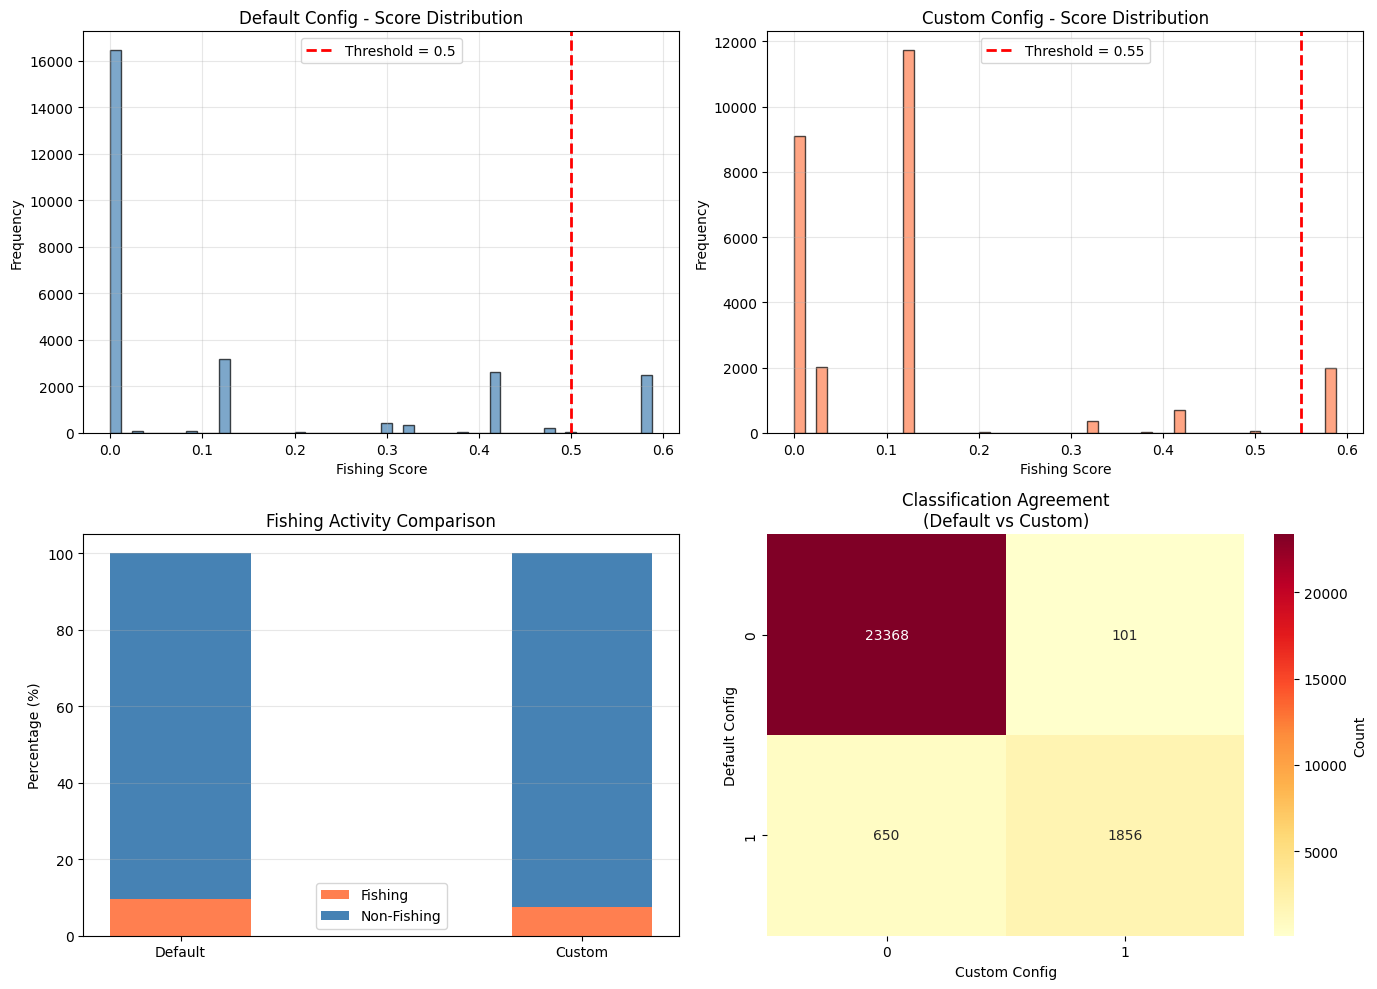

✓ Saved comparison visualization to: fishing_effort_outputs/config_comparison.png


In [11]:
# Compare score distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Default score distribution
ax = axes[0, 0]
ax.hist(predictions_v2_default['fishing_score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(clf_v2_default.config['fishing_score_threshold'], 
          color='red', linestyle='--', linewidth=2, label=f"Threshold = {clf_v2_default.config['fishing_score_threshold']}")
ax.set_xlabel('Fishing Score')
ax.set_ylabel('Frequency')
ax.set_title('Default Config - Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Custom score distribution
ax = axes[0, 1]
ax.hist(predictions_v2_custom['fishing_score'], bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(clf_v2_custom.config['fishing_score_threshold'], 
          color='red', linestyle='--', linewidth=2, label=f"Threshold = {clf_v2_custom.config['fishing_score_threshold']}")
ax.set_xlabel('Fishing Score')
ax.set_ylabel('Frequency')
ax.set_title('Custom Config - Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Detection comparison bar chart
ax = axes[1, 0]
configs = ['Default', 'Custom']
fishing_pcts = [fishing_pct_default, fishing_pct_custom]
nonfishing_pcts = [100-fishing_pct_default, 100-fishing_pct_custom]

x = np.arange(len(configs))
width = 0.35

ax.bar(x, fishing_pcts, width, label='Fishing', color='coral')
ax.bar(x, nonfishing_pcts, width, bottom=fishing_pcts, label='Non-Fishing', color='steelblue')

ax.set_ylabel('Percentage (%)')
ax.set_title('Fishing Activity Comparison')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Agreement matrix (confusion matrix style)
ax = axes[1, 1]
agreement = pd.crosstab(
    predictions_v2_default['is_fishing'], 
    predictions_v2_custom['is_fishing'],
    rownames=['Default'],
    colnames=['Custom']
)
sns.heatmap(agreement, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Classification Agreement\n(Default vs Custom)')
ax.set_ylabel('Default Config')
ax.set_xlabel('Custom Config')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/config_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved comparison visualization to: {OUTPUT_DIR}/config_comparison.png")

---
## 8. Configuration Tuning Guide

### 📋 Complete Configuration Parameters

The classifier has **23 configurable parameters** organized into 8 categories:

---

### 1️⃣ **Speed Thresholds** (km/h)

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `min_fishing_speed` | 0.5 | Minimum speed for fishing | ↓ Lower if slow-moving fishing (e.g., 0.2 for gillnet) |
| `max_fishing_speed` | 8.0 | Maximum speed for fishing | ↑ Higher if fast-moving fishing (e.g., 12.0 for some trawls) |
| `min_transit_speed` | 12.0 | Minimum speed for transit | ↓ Lower if vessel transits slowly |

**When to adjust:**
- **Under-detecting slow fishing** → Lower `min_fishing_speed` to 0.2-0.3
- **Catching transit as fishing** → Increase `max_fishing_speed` to 10-12
- **Missing fishing at higher speeds** → Increase `max_fishing_speed` to 10-12

---

### 2️⃣ **Turning Behavior**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `high_turn_threshold` | 45.0° | Minimum angle to count as "high turn" | ↓ Lower to 30-35° to detect gentler turning |
| `min_distance_for_turn` | 0.1 km | Minimum distance to validate a turn | ↓ Lower to 0.05 to catch tighter maneuvers |

**When to adjust:**
- **Missing turning behavior** → Lower `high_turn_threshold` to 30-35°
- **GPS noise causing false turns** → Increase `min_distance_for_turn` to 0.15-0.2
- **Gillnet/handline (more turning)** → Lower both parameters
- **Trawl/longline (less turning)** → Keep or increase both parameters

---

### 3️⃣ **Path Characteristics**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `low_straightness_threshold` | 0.4 | Below this = non-straight (fishing) | ↑ Increase to 0.5 for more meandering paths |
| `high_sinuosity_threshold` | 1.5 | Above this = tortuous (fishing) | ↓ Lower to 1.3 for less tortuous paths |

**When to adjust:**
- **Missing meandering fishing paths** → Increase `low_straightness_threshold` to 0.5-0.6
- **Catching straight transits** → Decrease `low_straightness_threshold` to 0.3
- **Missing tortuous fishing** → Lower `high_sinuosity_threshold` to 1.3-1.4
- **Over-detecting on curvy transit** → Increase `high_sinuosity_threshold` to 1.6-1.8

---

### 4️⃣ **Spatial Clustering**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `clustering_radius_km` | 0.5 | Radius to check for spatial clustering | ↑ Increase to 1.0-1.5 for dispersed fishing |
| `spatial_window_km` | 1.0 | Spatial window for feature calculation | ↑ Increase to 2.0 for wide-area fishing |

**When to adjust:**
- **Missing dispersed fishing** → Increase `clustering_radius_km` to 1.0-2.0
- **Gillnet (tight clustering)** → Keep or decrease to 0.3-0.5
- **Trawl (wide area)** → Increase to 1.5-2.0
- **Longline (moderate)** → Set to 0.8-1.2

---

### 5️⃣ **Speed Variability**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `high_speed_cv_threshold` | 0.6 | Coefficient of variation threshold | ↓ Lower to 0.5 for less variable fishing |

**What is CV?** Coefficient of Variation = std_dev / mean. Higher = more erratic speed.

**When to adjust:**
- **Missing start-stop fishing** → Lower to 0.4-0.5
- **Catching erratic transit** → Increase to 0.7-0.8

---

### 6️⃣ **Multi-Scale Windows**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `time_windows` | [10.0] | Time windows (minutes) for rolling stats | Add more: [5, 10, 30, 60] for multi-scale |
| `spatial_window_km` | 1.0 | Distance window for spatial features | ↑ Increase for coarse GPS or wide-area fishing |

**When to adjust:**
- **Irregular GPS sampling** → Keep time-based windows (already adaptive)
- **Want multi-scale analysis** → Use `[5, 10, 30]` for short/medium/long patterns
- **Fast fishing events** → Add shorter window: `[5, 10]`
- **Slow methodical fishing** → Add longer window: `[10, 30, 60]`

---

### 7️⃣ **State Machine Smoothing**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `min_state_duration` | 3 | Minimum consecutive points to maintain state | ↓ Lower to 1 for irregular GPS |

**⚠️ CRITICAL for Irregular GPS:**
- With 5-second GPS: `min_state_duration=3` = 15 seconds
- With 50-second GPS: `min_state_duration=3` = 150 seconds (!!)
- **Solution:** Set to **1** if GPS is irregular or sparse

**When to adjust:**
- **Irregular GPS (3s to 60s)** → Set to **1** (critical!)
- **Regular GPS + want smooth results** → Keep at 3 or increase to 5
- **Rapid state changes (fishing/transit/fishing)** → Lower to 1-2
- **Want to filter noise** → Increase to 5-7

---

### 8️⃣ **Feature Weights**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `weight_speed` | 3.0 | Importance of speed indicator | ↑ Increase if speed is most reliable indicator |
| `weight_turning` | 2.0 | Importance of turning behavior | ↑ Increase for gears with distinct turning |
| `weight_straightness` | 2.0 | Importance of path straightness | ↑ Increase if path shape is clear indicator |
| `weight_sinuosity` | 1.5 | Importance of path tortuosity | ↑ Increase for meandering fishing |
| `weight_clustering` | 2.0 | Importance of spatial clustering | ↑ Increase for stationary/clustered fishing |
| `weight_speed_variability` | 1.5 | Importance of speed changes | ↑ Increase for start-stop fishing |
| `weight_interaction_fishing_pattern` | 3.0 | Slow + turning + clustered combined | ↑ Increase if this combo is strong indicator |
| `weight_interaction_search_pattern` | 2.0 | Medium speed + high turning combined | ↑ Increase if searching is distinct |

**⚠️ Advanced - Rarely need to change!**
- Default weights work well for most cases
- Only adjust if you know specific indicators are more/less reliable in your fishery
- Increase a weight to make that feature more influential
- Weights are relative - doubling one makes it twice as important

---

### 9️⃣ **Classification Threshold**

| Parameter | Default | Description | Tuning Guide |
|-----------|---------|-------------|--------------|
| `fishing_score_threshold` | 0.5 | Minimum score to classify as fishing | ⭐ **MOST IMPORTANT PARAMETER** |

**This is the PRIMARY tuning knob:**
- **Under-detecting fishing** → Lower to **0.35-0.40**
- **Over-detecting fishing** → Raise to **0.55-0.60**
- **Very sensitive (catch everything)** → Lower to **0.25-0.30**
- **Very conservative (only obvious fishing)** → Raise to **0.65-0.70**

---

## 🎯 Quick Tuning Recipes

### 🔴 **Under-Detecting Fishing** (Missing actual fishing):
```python
# Quick fix (adjust these 4 parameters)
custom_config = {
    'fishing_score_threshold': 0.35,    # ↓ Most important
    'min_state_duration': 1,             # ↓ Critical for irregular GPS
    'max_fishing_speed': 10.0,          # ↑ Wider range
    'high_turn_threshold': 35.0,        # ↓ Catch gentler turns
}
```

### 🔵 **Over-Detecting Fishing** (Catching too much non-fishing):
```python
# Quick fix (adjust these 4 parameters)
custom_config = {
    'fishing_score_threshold': 0.60,    # ↑ Most important
    'min_state_duration': 5,             # ↑ More filtering
    'max_fishing_speed': 7.0,           # ↓ Narrower range
    'high_turn_threshold': 50.0,        # ↑ Only sharp turns
}
```

### ⚙️ **Gear-Specific Full Configs**

#### Gillnet (Slow, Clustered, High Turning):
```python
GILLNET_CONFIG = {
    # Speed
    'min_fishing_speed': 0.3,
    'max_fishing_speed': 4.0,           # Slower
    'min_transit_speed': 5.0,
    
    # Turning
    'high_turn_threshold': 35.0,        # More turning
    'min_distance_for_turn': 0.05,
    
    # Path
    'low_straightness_threshold': 0.50,
    'high_sinuosity_threshold': 1.5,
    
    # Spatial
    'clustering_radius_km': 0.6,        # Tighter clustering
    'spatial_window_km': 0.8,
    
    # Speed variability
    'high_speed_cv_threshold': 0.6,
    
    # Windows
    'time_windows': [10.0],
    
    # State machine
    'min_state_duration': 2,
    
    # Classification
    'fishing_score_threshold': 0.38,
}
```

#### Trawl (Faster, Straighter, Less Turning):
```python
TRAWL_CONFIG = {
    # Speed
    'min_fishing_speed': 2.0,
    'max_fishing_speed': 7.0,           # Faster
    'min_transit_speed': 8.0,
    
    # Turning
    'high_turn_threshold': 25.0,        # Less turning
    'min_distance_for_turn': 0.1,
    
    # Path
    'low_straightness_threshold': 0.35,  # Straighter
    'high_sinuosity_threshold': 1.3,
    
    # Spatial
    'clustering_radius_km': 2.0,        # More dispersed
    'spatial_window_km': 2.0,
    
    # Speed variability
    'high_speed_cv_threshold': 0.5,
    
    # Windows
    'time_windows': [10.0],
    
    # State machine
    'min_state_duration': 2,
    
    # Classification
    'fishing_score_threshold': 0.40,
}
```

#### Longline (Medium Everything):
```python
LONGLINE_CONFIG = {
    # Speed
    'min_fishing_speed': 1.0,
    'max_fishing_speed': 6.0,
    'min_transit_speed': 8.0,
    
    # Turning
    'high_turn_threshold': 30.0,
    'min_distance_for_turn': 0.08,
    
    # Path
    'low_straightness_threshold': 0.45,
    'high_sinuosity_threshold': 1.4,
    
    # Spatial
    'clustering_radius_km': 1.0,
    'spatial_window_km': 1.2,
    
    # Speed variability
    'high_speed_cv_threshold': 0.6,
    
    # Windows
    'time_windows': [10.0],
    
    # State machine
    'min_state_duration': 2,
    
    # Classification
    'fishing_score_threshold': 0.40,
}
```

---

## 💡 Iterative Tuning Process

1. **Start with default** → Run classification
2. **Check visualizations** → Review HTML/PNG maps
3. **Identify issue** → Under-detecting or over-detecting?
4. **Adjust PRIMARY parameters first:**
   - `fishing_score_threshold` (most important!)
   - `min_state_duration` (especially for irregular GPS)
   - `max_fishing_speed` (if speed-related issues)
   - `high_turn_threshold` (if turning-related issues)
5. **Re-run and compare** → Did it improve?
6. **Fine-tune SECONDARY parameters** if needed
7. **Repeat** until satisfied

---

## 🚫 Common Mistakes

❌ **Adjusting weights without understanding** → Leave weights at defaults unless you're sure  
❌ **Using `min_state_duration > 1` with irregular GPS** → Always set to 1 for variable GPS  
❌ **Changing too many parameters at once** → Change 1-2 at a time  
❌ **Not visualizing results** → Always check maps after tuning  
❌ **Forgetting `fishing_score_threshold`** → This is the most important parameter!  

---

## 📚 Parameter Priority Guide

### **⭐⭐⭐ Always Adjust These First:**
1. `fishing_score_threshold` - Primary sensitivity control
2. `min_state_duration` - Critical for irregular GPS
3. `max_fishing_speed` - If speed-based issues

### **⭐⭐ Adjust These Second:**
4. `high_turn_threshold` - If turning issues
5. `clustering_radius_km` - If spatial pattern issues
6. `low_straightness_threshold` - If path shape issues

### **⭐ Rarely Need to Adjust:**
7. All weight parameters - Only for advanced tuning
8. `time_windows` - Usually keep at [10.0]
9. `spatial_window_km` - Usually keep at 1.0

### **❌ Almost Never Adjust:**
10. `min_distance_for_turn` - Filters GPS noise
11. Feature interaction weights - Advanced users only

---